# **Mobile Money – Détection de fraude transactionnelle**

# **----------------------------------------------------------------------**

## **1. Chargement et aperçu de la base**

In [113]:
#Importation des bibliothèques utiles 
import numpy as np #pour du calcul numérique
import pandas as pd #pour la manipulation de données
import seaborn as sns #pour de la visualisation
from matplotlib import pyplot as plt #pour de la visualisation

In [114]:
#chargement de la base de données
df = pd.read_csv(filepath_or_buffer = 'mobile_money.csv', 
                 sep = "," , encoding = "utf8")
#apperçu
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [115]:
#Transformons la variables step qui represente une unité de temps en jours et heures
df["day"] = df["step"] // 24 + 1
df["hour"] = df["step"] % 24 

df.drop(columns=["step"], inplace=True)

In [116]:
#Sur recommandation on supprime ces colonnes
df = df.drop([
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
], axis=1)

In [117]:
df.head()

,type,amount,nameOrig,nameDest,isFraud,isFlaggedFraud,day,hour
0,PAYMENT,9839.64,C1231006815,M1979787155,0,0,1,1
1,PAYMENT,1864.28,C1666544295,M2044282225,0,0,1,1
2,TRANSFER,181.00,C1305486145,C553264065,1,0,1,1
3,CASH_OUT,181.00,C840083671,C38997010,1,0,1,1
4,PAYMENT,11668.14,C2048537720,M1230701703,0,0,1,1


## **2. Analyse exploratoire**

### **2.1 Analyse de forme**

In [118]:
#description de la forme de la base 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   type            str    
 1   amount          float64
 2   nameOrig        str    
 3   nameDest        str    
 4   isFraud         int64  
 5   isFlaggedFraud  int64  
 6   day             int64  
 7   hour            int64  
dtypes: float64(1), int64(4), str(3)
memory usage: 388.3 MB


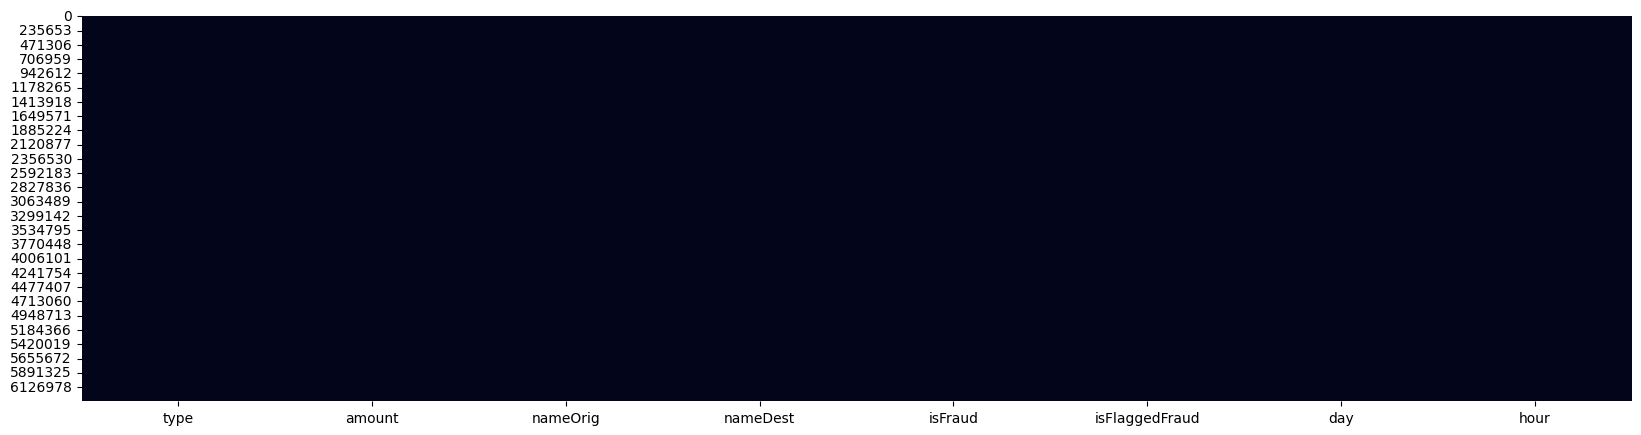

In [119]:
#visualisation des données manquantes
plt.figure(figsize = (20 , 5))
sns.heatmap( data = df.isnull() , cbar = False )
plt.show()

In [120]:
#nombre de modalités uniques
for index , value in zip(df.nunique().index , df.nunique().values) :
    print(f'{index:-<40}{value}')

type------------------------------------5
amount----------------------------------5316900
nameOrig--------------------------------6353307
nameDest--------------------------------2722362
isFraud---------------------------------2
isFlaggedFraud--------------------------2
day-------------------------------------31
hour------------------------------------24


In [121]:
#analyse des données dupliquées (doublons)
df.duplicated().sum()

np.int64(0)

### **2.2 Analyse de fond**

#### **Analyse  univariée**

##### **Variables quantitatives**

In [122]:
#liste des variables considérées comme quantitative
num_cols = df.select_dtypes(include=np.number).columns.tolist()
#affichage
num_cols

['amount', 'isFraud', 'isFlaggedFraud', 'day', 'hour']

In [123]:
#statistiques descriptives des variables quantitatives
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
amount,6362620.0,179861.903549,603858.231463,0.0,13389.57,74871.94,208721.4775,92445516.64
isFraud,6362620.0,0.001291,0.035905,0.0,0.00,0.00,0.0000,1.00
isFlaggedFraud,6362620.0,0.000003,0.001586,0.0,0.00,0.00,0.0000,1.00
day,6362620.0,10.503158,5.922111,1.0,7.00,10.00,14.0000,31.00
hour,6362620.0,15.321454,4.321799,0.0,12.00,16.00,19.0000,23.00


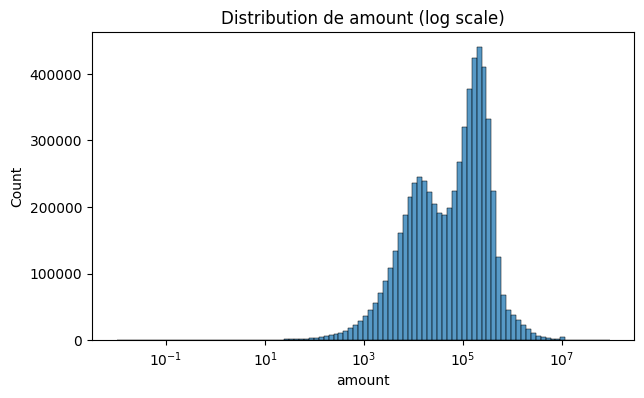

In [124]:
plt.figure(figsize=(7,4))
sns.histplot(df["amount"], bins=100, log_scale=True)
plt.title("Distribution de amount (log scale)")
plt.show()

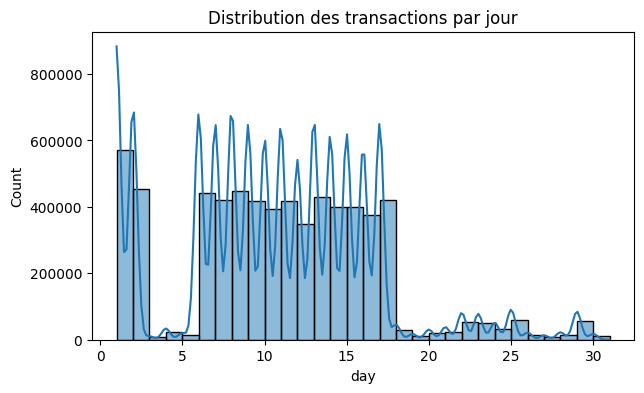

In [125]:
plt.figure(figsize=(7,4))
sns.histplot(df["day"], bins=30, kde=True)
plt.title("Distribution des transactions par jour")
plt.show()

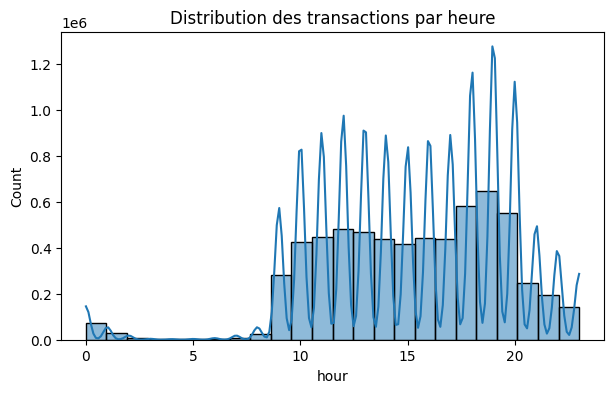

In [126]:
plt.figure(figsize=(7,4))
sns.histplot(df["hour"], bins=24, kde=True)
plt.title("Distribution des transactions par heure")
plt.show()

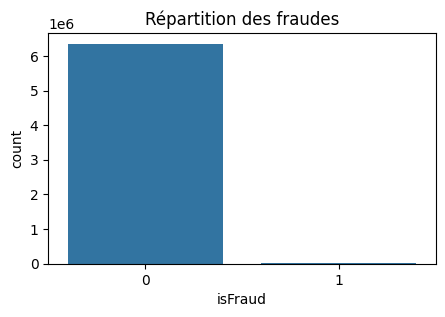

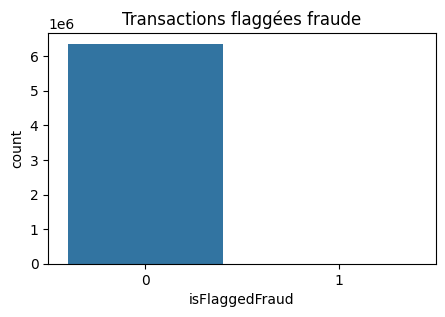

In [127]:
plt.figure(figsize=(5,3))
sns.countplot(x="isFraud", data=df)
plt.title("Répartition des fraudes")
plt.show()

plt.figure(figsize=(5,3))
sns.countplot(x="isFlaggedFraud", data=df)
plt.title("Transactions flaggées fraude")
plt.show()

##### **Variables qualitatives**

In [128]:
#liste des variables qualitatives
cat_cols = df.select_dtypes(exclude = np.number).columns.tolist()
#affichage
cat_cols

['type', 'nameOrig', 'nameDest']

In [129]:
#description des variables qualitatives
df[cat_cols].describe(include = 'all').T

,count,unique,top,freq
type,6362620,5,CASH_OUT,2237500
nameOrig,6362620,6353307,C2098525306,3
nameDest,6362620,2722362,C1286084959,113


In [130]:
#suppresion de nameOrig puisque les valeurs sont toutes presques uniques
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
cat_cols.remove("nameOrig")

In [131]:
#Nouvelle description des variables qualitatives
df[cat_cols].describe(include = 'all').T

,count,unique,top,freq
type,6362620,5,CASH_OUT,2237500
nameDest,6362620,2722362,C1286084959,113


#### **Analyse  bivariée**

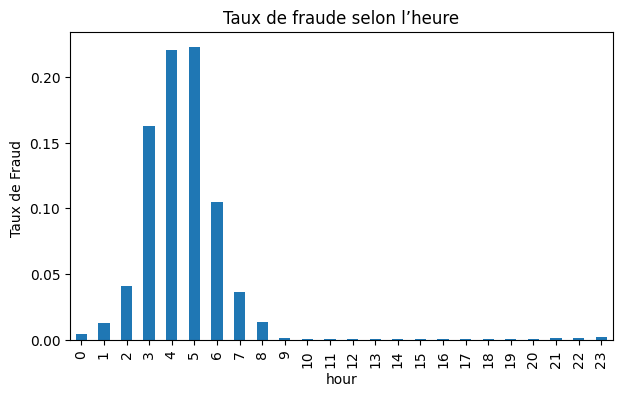

In [132]:
#Le taux de fraude varie selon l’heure de la journée.
df.groupby("hour")["isFraud"].mean().plot(kind="bar", figsize=(7,4))
plt.title("Taux de fraude selon l’heure")
plt.ylabel("Taux de Fraud ")
plt.show()

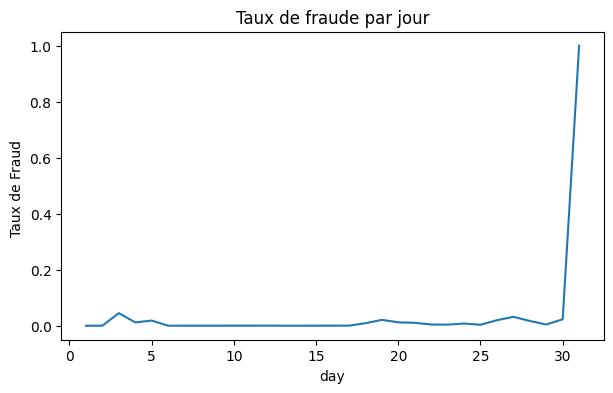

In [133]:
#variation du taux de fraude au cours des jours
df.groupby("day")["isFraud"].mean().plot(figsize=(7,4))
plt.title("Taux de fraude par jour")
plt.ylabel("Taux de Fraud ")
plt.show()


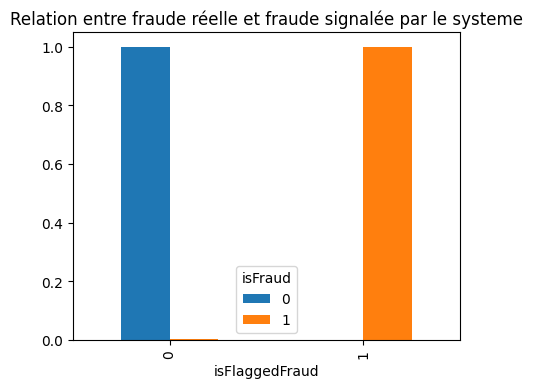

In [134]:
pd.crosstab(df["isFlaggedFraud"], df["isFraud"], normalize="index").plot(kind="bar", figsize=(5,4))
plt.title("Relation entre fraude réelle et fraude signalée par le systeme")
plt.show()

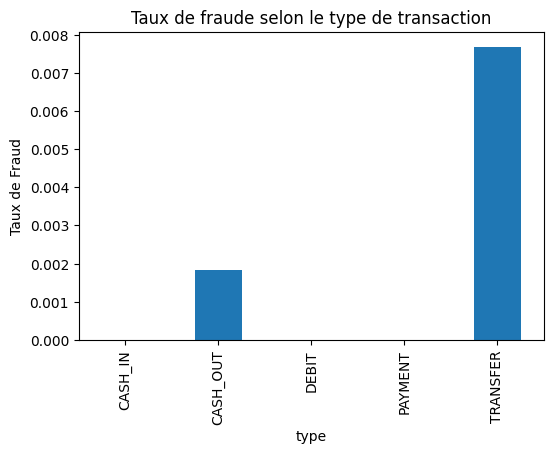

In [135]:
df.groupby("type")["isFraud"].mean().plot(kind="bar", figsize=(6,4))
plt.title("Taux de fraude selon le type de transaction")
plt.ylabel("Taux de Fraud")
plt.show()

In [144]:
#liste de toutes les variables retenues
liste = num_cols.copy()
liste.extend(cat_cols)
#nouveau dataframe
new_df = df[liste]
#apperçu 
new_df.head()

,amount,isFraud,isFlaggedFraud,day,hour,type,nameDest
0,9839.64,0,0,1,1,PAYMENT,M1979787155
1,1864.28,0,0,1,1,PAYMENT,M2044282225
2,181.00,1,0,1,1,TRANSFER,C553264065
3,181.00,1,0,1,1,CASH_OUT,C38997010
4,11668.14,0,0,1,1,PAYMENT,M1230701703


## **3. Preprocessing**

In [145]:
#description de la base retenue
new_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   amount          float64
 1   isFraud         int64  
 2   isFlaggedFraud  int64  
 3   day             int64  
 4   hour            int64  
 5   type            str    
 6   nameDest        str    
dtypes: float64(1), int64(4), str(2)
memory usage: 339.8 MB


In [146]:
#les valeurs de la variables Type
new_df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [147]:
#nombre de modalités uniques
for index , value in zip(new_df.nunique().index , new_df.nunique().values) :
    print(f'{index:-<40}{value}')

amount----------------------------------5316900
isFraud---------------------------------2
isFlaggedFraud--------------------------2
day-------------------------------------31
hour------------------------------------24
type------------------------------------5
nameDest--------------------------------2722362


In [148]:
#Transformation de la colonne Type en des colonnes binaires
new_df = pd.get_dummies(new_df, columns=["type"], drop_first=True, dtype=int)
new_df

,amount,isFraud,isFlaggedFraud,day,hour,nameDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,9839.64,0,0,1,1,M1979787155,0,0,1,0
1,1864.28,0,0,1,1,M2044282225,0,0,1,0
2,181.00,1,0,1,1,C553264065,0,0,0,1
3,181.00,1,0,1,1,C38997010,1,0,0,0
4,11668.14,0,0,1,1,M1230701703,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
6362615,339682.13,1,0,31,23,C776919290,1,0,0,0
6362616,6311409.28,1,0,31,23,C1881841831,0,0,0,1
6362617,6311409.28,1,0,31,23,C1365125890,1,0,0,0
6362618,850002.52,1,0,31,23,C2080388513,0,0,0,1


In [149]:
#transformation de la variable nameDest en binaire pour savoir si c'est le destinataire est un  marchant ou un client 
new_df["isMerchantDest"] = new_df["nameDest"].str.startswith("M").astype(int)

In [150]:
new_df

,amount,isFraud,isFlaggedFraud,day,hour,nameDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,isMerchantDest
0,9839.64,0,0,1,1,M1979787155,0,0,1,0,1
1,1864.28,0,0,1,1,M2044282225,0,0,1,0,1
2,181.00,1,0,1,1,C553264065,0,0,0,1,0
3,181.00,1,0,1,1,C38997010,1,0,0,0,0
4,11668.14,0,0,1,1,M1230701703,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...
6362615,339682.13,1,0,31,23,C776919290,1,0,0,0,0
6362616,6311409.28,1,0,31,23,C1881841831,0,0,0,1,0
6362617,6311409.28,1,0,31,23,C1365125890,1,0,0,0,0
6362618,850002.52,1,0,31,23,C2080388513,0,0,0,1,0


In [151]:
new_df.drop(columns=["nameDest"], inplace=True)
new_df

,amount,isFraud,isFlaggedFraud,day,hour,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,isMerchantDest
0,9839.64,0,0,1,1,0,0,1,0,1
1,1864.28,0,0,1,1,0,0,1,0,1
2,181.00,1,0,1,1,0,0,0,1,0
3,181.00,1,0,1,1,1,0,0,0,0
4,11668.14,0,0,1,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...
6362615,339682.13,1,0,31,23,1,0,0,0,0
6362616,6311409.28,1,0,31,23,0,0,0,1,0
6362617,6311409.28,1,0,31,23,1,0,0,0,0
6362618,850002.52,1,0,31,23,0,0,0,1,0


In [152]:
#verifions le rapport entre les deux relations
pd.crosstab(new_df["isFlaggedFraud"], new_df["isFraud"])

isFraud,0,1
isFlaggedFraud,,
0,6354407,8197
1,0,16


- Les 16 transactions pour lesquelles isFlaggedFraud = 1 sont toutes des fraudes réelles.
- Il n'existe aucun faux positif (isFlaggedFraud = 1 et isFraud = 0).
- En revanche, 8 197 fraudes ne sont pas signalées (isFlaggedFraud = 0 alors que isFraud = 1).

Conclusion : Précision de isFlaggedFraud = 100 % on choisit de l'ecarter parceque c'est un sous ensemble de isFraud et que isFraud represente la realite du dataset. 

In [154]:
new_df.drop(columns=["isFlaggedFraud"], inplace=True)
new_df

,amount,isFraud,day,hour,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,isMerchantDest
0,9839.64,0,1,1,0,0,1,0,1
1,1864.28,0,1,1,0,0,1,0,1
2,181.00,1,1,1,0,0,0,1,0
3,181.00,1,1,1,1,0,0,0,0
4,11668.14,0,1,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...
6362615,339682.13,1,31,23,1,0,0,0,0
6362616,6311409.28,1,31,23,0,0,0,1,0
6362617,6311409.28,1,31,23,1,0,0,0,0
6362618,850002.52,1,31,23,0,0,0,1,0


## **4. Création des Modeles**

In [198]:
from sklearn.model_selection import train_test_split

# On sépare features (X) et cible (y)
X = new_df.drop(columns=["isFraud"])
y = new_df["isFraud"]

# Split stratifié : garde la même proportion de fraude dans train et test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Vérification 1 : répartition des classes dans y_train
print(y_train.value_counts())

# Vérification 2 : X_train et y_train ont bien le même nombre de lignes
print(X_train.shape)  
print(y_train.shape)  

isFraud
0    5083526
1       6570
Name: count, dtype: int64
(5090096, 8)
(5090096,)


In [213]:
new_df

,amount,isFraud,day,hour,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,isMerchantDest
0,9839.64,0,1,1,0,0,1,0,1
1,1864.28,0,1,1,0,0,1,0,1
2,181.00,1,1,1,0,0,0,1,0
3,181.00,1,1,1,1,0,0,0,0
4,11668.14,0,1,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...
6362615,339682.13,1,31,23,1,0,0,0,0
6362616,6311409.28,1,31,23,0,0,0,1,0
6362617,6311409.28,1,31,23,1,0,0,0,0
6362618,850002.52,1,31,23,0,0,0,1,0


In [212]:
y

0          0
1          0
2          1
3          1
4          0
          ..
6362615    1
6362616    1
6362617    1
6362618    1
6362619    1
Name: isFraud, Length: 6362620, dtype: int64

### **4.1 Gestion desequilibre**

#### **- SMOTE**

In [199]:
from imblearn.over_sampling import SMOTE

# SMOTE crée des exemples synthétiques de fraude
# en interpolant entre des transactions frauduleuses proches
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Vérification : les classes doivent maintenant être équilibrées (50/50)
print(y_train_smote.value_counts())

isFraud
0    5083526
1    5083526
Name: count, dtype: int64


#### **- UnderSampler**

In [200]:
from imblearn.under_sampling import RandomUnderSampler

# Réduit aléatoirement le nombre de transactions non-fraude
# pour équilibrer avec le nombre de fraudes
undersampler = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = undersampler.fit_resample(X_train, y_train)

# Vérification : les classes doivent être équilibrées (50/50)
print(y_train_under.value_counts())

isFraud
0    6570
1    6570
Name: count, dtype: int64


#### **- OverSampler**

In [201]:
from imblearn.over_sampling import RandomOverSampler

# Duplique aléatoirement des transactions frauduleuses existantes
# jusqu'à équilibrer les classes (contrairement à SMOTE, pas de
# génération synthétique, on répète juste des exemples réels)
oversampler = RandomOverSampler(random_state=42)

X_train_over, y_train_over = oversampler.fit_resample(X_train, y_train)

# Vérification : les classes doivent être équilibrées (50/50)
print(y_train_over.value_counts())

isFraud
0    5083526
1    5083526
Name: count, dtype: int64


### **4.2 Modeles avec chaque gestion de desequilibre**

#### **- Random Forest**

In [202]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# On entraîne un Random Forest sur chaque version du train set
train_versions = {
    "original": (X_train, y_train),
    "SMOTE": (X_train_smote, y_train_smote),
    "Undersampling": (X_train_under, y_train_under),
    "Oversampling": (X_train_over, y_train_over),
}

for nom, (X_tr, y_tr) in train_versions.items():
    print(f"\n===== Random Forest - {nom} =====")
    
    rf = RandomForestClassifier(random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    
    y_pred = rf.predict(X_test)
    print(classification_report(y_test, y_pred, digits=3))


===== Random Forest - original =====
              precision    recall  f1-score   support

           0      0.999     1.000     1.000   1270881
           1      0.746     0.469     0.576      1643

    accuracy                          0.999   1272524
   macro avg      0.873     0.734     0.788   1272524
weighted avg      0.999     0.999     0.999   1272524


===== Random Forest - SMOTE =====
              precision    recall  f1-score   support

           0      1.000     0.985     0.992   1270881
           1      0.052     0.629     0.096      1643

    accuracy                          0.985   1272524
   macro avg      0.526     0.807     0.544   1272524
weighted avg      0.998     0.985     0.991   1272524


===== Random Forest - Undersampling =====
              precision    recall  f1-score   support

           0      1.000     0.886     0.940   1270881
           1      0.010     0.899     0.020      1643

    accuracy                          0.886   1272524
   macro avg

**Le test avec les donnees initiales sans equilibrage donne de meilleurs performances**

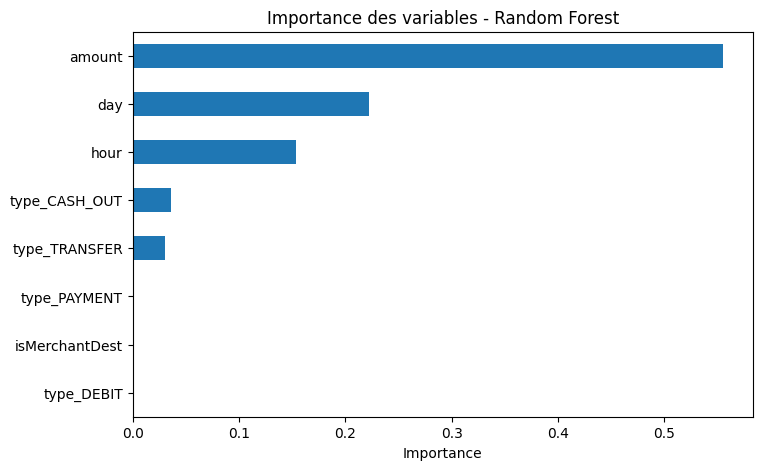

In [214]:
# ===== Feature importance du Random Forest (originale) =====
import matplotlib.pyplot as plt
import pandas as pd

# On réentraîne le modèle "original" pour récupérer ses feature_importances_
# (le rf de la boucle précédente ne garde que la dernière version testée, Oversampling)
rf_original = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_original.fit(X_train, y_train)

# feature_importances_ donne un score d'importance pour chaque colonne
importances = pd.Series(rf_original.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.title("Importance des variables - Random Forest")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

**isMerchantDest ressort à quasi 0, or l'analyse bivariée avait montré que les marchands sont rarement ciblés. on peux deduire cette information est déjà largement capturée par type_PAYMENT/type_CASH_OUT  — Random Forest a donc trouvé l'info redondante et n'a pas eu besoin de s'appuyer dessus. Malgré une corrélation observée dans l'analyse bivariée, cette variable s'avère redondante avec type en présence des autres features".**

#### **- Gradiant Boost**

In [203]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report

# On entraîne un Gradient Boosting sur chaque version du train set
for nom, (X_tr, y_tr) in train_versions.items():
    print(f"\n===== Gradient Boosting - {nom} =====")
    
    gb = HistGradientBoostingClassifier(random_state=42)
    gb.fit(X_tr, y_tr)
    
    y_pred = gb.predict(X_test)
    print(classification_report(y_test, y_pred, digits=3))


===== Gradient Boosting - original =====
              precision    recall  f1-score   support

           0      0.999     1.000     0.999   1270881
           1      0.504     0.292     0.370      1643

    accuracy                          0.999   1272524
   macro avg      0.752     0.646     0.685   1272524
weighted avg      0.998     0.999     0.999   1272524


===== Gradient Boosting - SMOTE =====
              precision    recall  f1-score   support

           0      1.000     0.931     0.964   1270881
           1      0.015     0.794     0.029      1643

    accuracy                          0.931   1272524
   macro avg      0.507     0.863     0.497   1272524
weighted avg      0.998     0.931     0.963   1272524


===== Gradient Boosting - Undersampling =====
              precision    recall  f1-score   support

           0      1.000     0.902     0.948   1270881
           1      0.012     0.904     0.023      1643

    accuracy                          0.902   1272524


**- Constat global : Random Forest sur données originales  donne de meilleurs performances — meilleur F1-score (0.576) et de loin la meilleure precision (0.746). Ce modele  gère déjà bien le déséquilibre nativement grâce au bagging (chaque arbre voit un sous-échantillon différent), donc le rééquilibrage artificiel lui apporte plus de bruit que d'aide ici.**

**Pour les autres modeles plus on applique les methodes d'equilibre plus la precision baisse**

### **4.3 Evaluation selon les differents seuils du modele choisi**

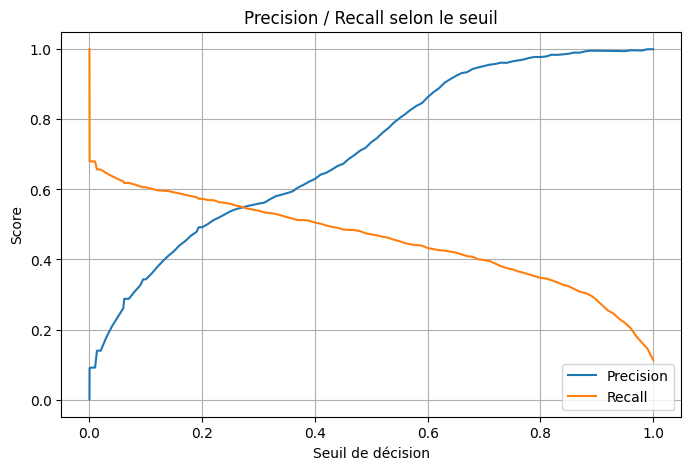

In [205]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# On réentraîne le modèle gagnant : Random Forest sur données originales
rf_final = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

# Au lieu de predict() (seuil fixe à 0.5), on récupère les probabilités
# predict_proba renvoie [proba_classe_0, proba_classe_1] -> on garde la classe 1 (fraude)
y_proba = rf_final.predict_proba(X_test)[:, 1]

# precision_recall_curve calcule precision et recall pour tous les seuils possibles
precision, recall, seuils = precision_recall_curve(y_test, y_proba)

# Affichage du graphique
plt.figure(figsize=(8, 5))
plt.plot(seuils, precision[:-1], label="Precision")
plt.plot(seuils, recall[:-1], label="Recall")
plt.xlabel("Seuil de décision")
plt.ylabel("Score")
plt.title("Precision / Recall selon le seuil")
plt.legend()
plt.grid(True)
plt.show()

In [206]:
# Calcul du F1-score pour chaque seuil testé
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)  # +1e-9 évite division par zéro

# Seuil qui maximise le F1-score
meilleur_index = np.argmax(f1_scores)
meilleur_seuil = seuils[meilleur_index]

print(f"Meilleur seuil : {meilleur_seuil:.3f}")
print(f"Precision à ce seuil : {precision[meilleur_index]:.3f}")
print(f"Recall à ce seuil : {recall[meilleur_index]:.3f}")
print(f"F1-score à ce seuil : {f1_scores[meilleur_index]:.3f}")

Meilleur seuil : 0.530
Precision à ce seuil : 0.774
Recall à ce seuil : 0.462
F1-score à ce seuil : 0.579


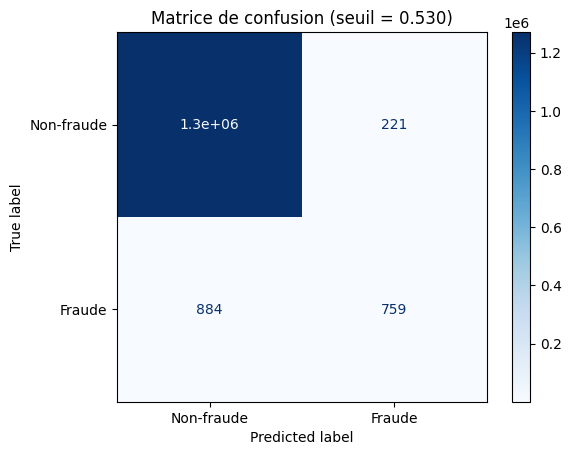

In [208]:
# ===== Matrice de confusion au seuil optimal =====
from sklearn.metrics import ConfusionMatrixDisplay


y_pred_seuil_optimal = (y_proba >= meilleur_seuil).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_seuil_optimal,
    display_labels=["Non-fraude", "Fraude"],
    cmap="Blues"
)
plt.title(f"Matrice de confusion (seuil = {meilleur_seuil:.3f})")
plt.show()

### **4.4 Modele final**

In [207]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import joblib

# 1. Entraînement du modèle final : Random Forest, données originales (sans resampling)
modele_final = RandomForestClassifier(random_state=42, n_jobs=-1)
modele_final.fit(X_train, y_train)

# 2. Application du seuil optimal (0.530) au lieu du seuil par défaut (0.5)
y_proba = modele_final.predict_proba(X_test)[:, 1]
SEUIL = 0.530
y_pred_final = (y_proba >= SEUIL).astype(int)

# 3. Vérification finale des performances
print(classification_report(y_test, y_pred_final, digits=3))

              precision    recall  f1-score   support

           0      0.999     1.000     1.000   1270881
           1      0.774     0.462     0.579      1643

    accuracy                          0.999   1272524
   macro avg      0.887     0.731     0.789   1272524
weighted avg      0.999     0.999     0.999   1272524



PR-AUC du modèle final : 0.546


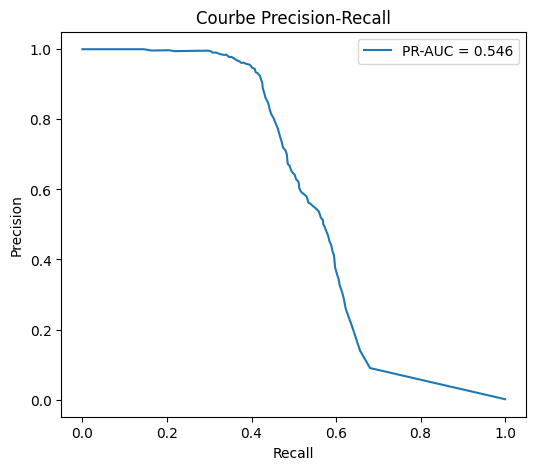

In [216]:
# ===== PR-AUC : métrique unique pour comparer objectivement les modèles =====
from sklearn.metrics import average_precision_score, precision_recall_curve

pr_auc = average_precision_score(y_test, y_proba)
print(f"PR-AUC du modèle final : {pr_auc:.3f}")
# Plus proche de 1 = meilleur. Contrairement au F1, ne dépend pas d'un seuil fixe.

# Courbe Precision-Recall (visualisation de l'aire calculée ci-dessus)
precision_pr, recall_pr, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall_pr, precision_pr, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall")
plt.legend()
plt.show()

ROC-AUC du modèle final : 0.838


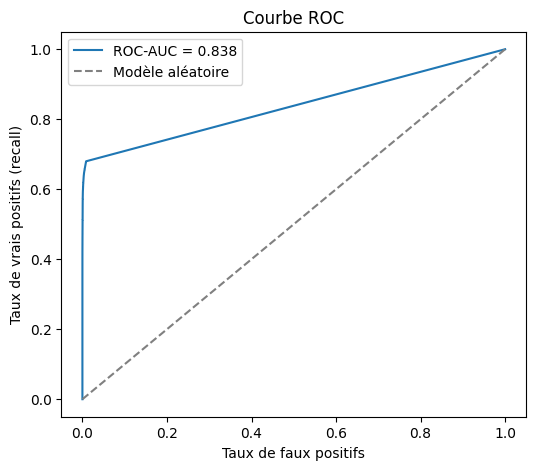

In [215]:
# ===== ROC-AUC : métrique de référence dans le secteur financier =====
from sklearn.metrics import roc_auc_score, roc_curve

# roc_auc_score prend les probabilités (pas les prédictions binaires)
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC du modèle final : {roc_auc:.3f}")

# Courbe ROC (visualisation du compromis taux de vrais positifs / faux positifs)
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Modèle aléatoire")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs (recall)")
plt.title("Courbe ROC")
plt.legend()
plt.show()

**> ROC-AUC regarde si le modèle sépare bien les fraudes des transactions normales, mais comme il y a très peu de fraudes (0,13%), même beaucoup de fausses alertes paraissent négligeables dans le calcul — le score reste donc élevé et un peu trompeur. PR-AUC est plus adequatdans ce cas, il regarde parmi les transactions signalées comme fraude, combien le sont vraiment.**

In [210]:
joblib.dump(modele_final, "modele_fraude_random_forest.pkl")
print(f"Modèle sauvegardé. Seuil optimal à réutiliser : {SEUIL}")

Modèle sauvegardé. Seuil optimal à réutiliser : 0.53
